In [1]:
import sys
sys.version

'3.12.0 | packaged by Anaconda, Inc. | (main, Oct  2 2023, 17:20:38) [MSC v.1916 64 bit (AMD64)]'

# Step 2: data collection

In [2]:
import pandas as pd 
df = pd.read_csv(r"data/raw/Cars24_Used_Cars_Raw_Data.csv")
df

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,"55,160 km",₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,"84,719 km",₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,"34,483 km",₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,"46,327 km",₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,"98,516 km",₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual
...,...,...,...,...,...,...,...,...,...
3147,Volkswagen,Vento COMFORTLINE 1.,2011,Coimbatore,"695,604 km",₹1.09 lakh,Not available on EMI,Petrol,Manual
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,"55,404 km",₹2.39 lakh,Not available on EMI,Diesel,Manual
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,"53,441 km",₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,"94,479 km",₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual


## Data Understanding 

#### Data Types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3152 entries, 0 to 3151
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Brand       3152 non-null   str  
 1   Variant     3152 non-null   str  
 2   Model Year  3152 non-null   int64
 3   City        3152 non-null   str  
 4   Kilometer   3152 non-null   str  
 5   Price       3152 non-null   str  
 6   EMI         3152 non-null   str  
 7   Fuel_Type   3139 non-null   str  
 8   Drive_Mode  3152 non-null   str  
dtypes: int64(1), str(8)
memory usage: 221.8 KB


# Step 3 : EDA

#### missing values check 

In [4]:
df.isna().sum()

Brand          0
Variant        0
Model Year     0
City           0
Kilometer      0
Price          0
EMI            0
Fuel_Type     13
Drive_Mode     0
dtype: int64

### Duplicates records 

In [5]:
df.duplicated().sum()

np.int64(0)

## Stats Features 

In [6]:
df.describe()

,Model Year
count,3152.000000
mean,2018.112627
std,3.528234
min,2008.000000
25%,2016.000000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [8]:
df.describe(include="all")

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
count,3152,3152,3152.000000,3152,3152,3152,3152,3139,3152
unique,11,1007,NaN,15,2875,2350,2040,4,2
top,Maruti,Ecosport TITANIUM 1.5L DIESEL,NaN,New-delhi,"00,000 km",₹5.10 lakh,Not available on EMI,Petrol,Manual
freq,340,46,NaN,406,4,8,206,2134,2349
mean,NaN,NaN,2018.112627,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3.528234,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN


## value counts of key categorical features 

In [9]:
df["Brand"].value_counts()

Brand
Maruti        340
Tata          338
Hyundai       331
Honda         327
Mahindra      306
Renault       300
Ford          293
KIA           280
Toyota        274
Volkswagen    257
BMW           106
Name: count, dtype: int64

In [10]:
df["City"].value_counts()

City
New-delhi     406
Noida         401
Hyderabad     219
Mumbai        214
Bangalore     209
Pune          208
Ahmedabad     207
Chennai       199
Kolkata       187
Lucknow       185
Jaipur        176
Agra          159
Surat         152
Kochi         137
Coimbatore     93
Name: count, dtype: int64

In [11]:
df["Fuel_Type"].value_counts()

Fuel_Type
Petrol      2134
Diesel       877
CNG          122
Electric       6
Name: count, dtype: int64

In [12]:
df["Drive_Mode"].value_counts()

Drive_Mode
Manual    2349
Auto       803
Name: count, dtype: int64

In [21]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'Price', 'EMI',
       'Fuel_Type', 'Drive_Mode'],
      dtype='str')

## Varaints 

In [22]:
df["Variant"]

0                        Zest XE PETROL
1       NEXON XZA PLUS PETROL DUAL TONE
2                   TIGOR XZ (O) PETROL
3                        Nano TWIST XTA
4                       Tiago XE DIESEL
                     ...               
3147               Vento COMFORTLINE 1.
3148           Vento HIGHLINE DIESEL 1.
3149                 Polo 1.0 GT TSI AT
3150                  Polo HIGHLINE1.2L
3151           Vento HIGHLINE PETROL AT
Name: Variant, Length: 3139, dtype: str

### 'Kilometer'

In [28]:
df['Kilometer'] = df['Kilometer'].str.replace(" km", "").str.replace(",","").astype(int)

In [29]:
min(df['Kilometer']), max(df['Kilometer'])

(0, 990803)

In [31]:
import matplotlib.pyplot as plt 
import seaborn as sns 

<Axes: ylabel='Frequency'>

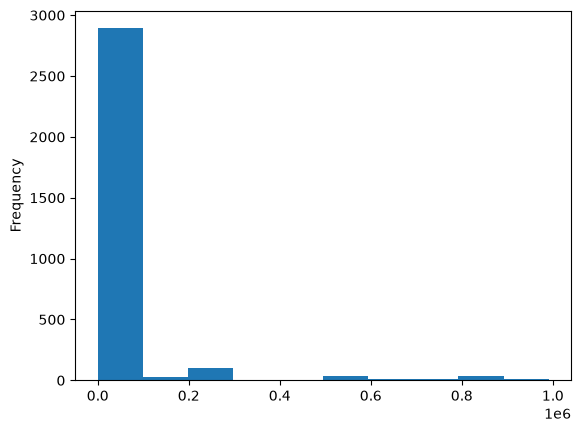

In [33]:
df['Kilometer'].plot(kind="hist")

<Axes: ylabel='Density'>

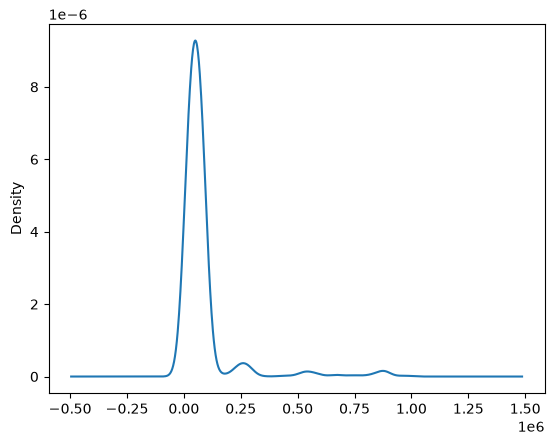

In [35]:
df['Kilometer'].plot(kind="kde")

C:\Users\shrid\AppData\Local\Temp\ipykernel_34616\2064738825.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Kilometer"])


<Axes: xlabel='Kilometer', ylabel='Density'>

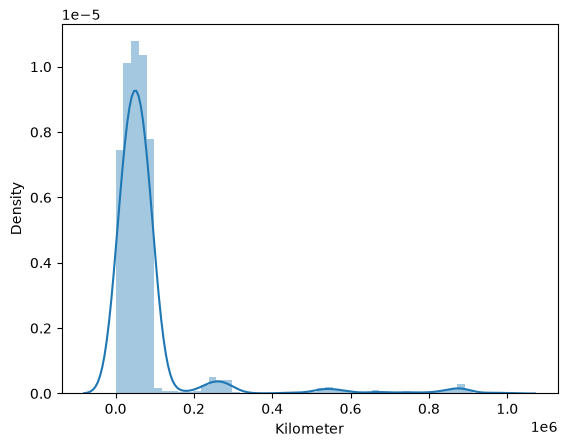

In [36]:
sns.distplot(df["Kilometer"])

<Axes: >

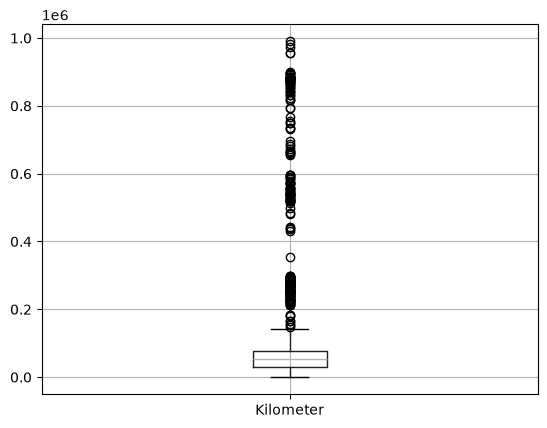

In [38]:
df[["Kilometer"]].boxplot()

In [40]:
df["Kilometer"].quantile(0.75)

np.float64(77151.0)

In [41]:
IQR = df["Kilometer"].quantile(0.75) - df["Kilometer"].quantile(0.25)
IQR

np.float64(46620.0)

In [43]:
upper_tail = df["Kilometer"].quantile(0.75)  + (1.5 * IQR) 
upper_tail

np.float64(147081.0)

In [44]:
df["Kilometer"].quantile(0.90)

np.float64(95700.6)

In [45]:
df["Kilometer"].quantile(0.95)

np.float64(269012.8)

In [46]:
df["Kilometer"].quantile(0.99)

np.float64(866555.2799999999)

In [47]:
df[df["Kilometer"] <= 600000]

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual
...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,₹10.94 lakh,"EMI ₹18,730/m*",Petrol,Auto
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,₹2.39 lakh,Not available on EMI,Diesel,Manual
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual


In [48]:
df.shape

(3139, 9)

In [49]:
3139 - 3073

66

In [50]:
df[df["Kilometer"] <= 500000]

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual
...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,₹10.94 lakh,"EMI ₹18,730/m*",Petrol,Auto
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,₹2.39 lakh,Not available on EMI,Diesel,Manual
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual


In [51]:
3139 - 3032

107

In [52]:
 df1 = df[df["Kilometer"] <= 500000]

<Axes: >

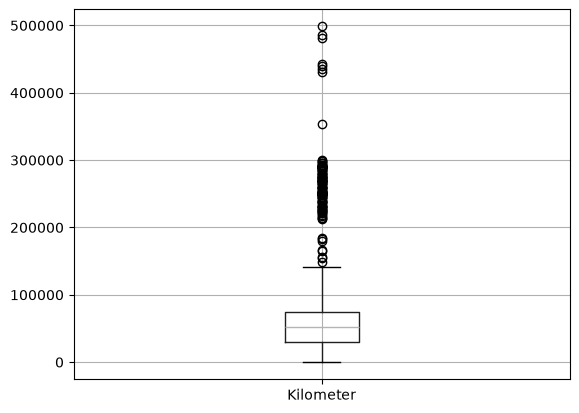

In [54]:
df1[["Kilometer"]].boxplot()

### observations 

In [ ]:
1. it contains lot of outliers
2. 90th percentile value is 95700 and rest 90th to 10th percentile values are huge. 
3. upper_tail from outlier also crossing this observations 
#### Conclusion 
as 95th perctile value is around 250000 so filtering the samples belwo 500000 


In [56]:
 df = df[df["Kilometer"] <= 500000]

In [58]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'Price', 'EMI',
       'Fuel_Type', 'Drive_Mode'],
      dtype='str')

## Price 

In [59]:
df["Price"].head()

0          ₹2.59 lakh
1    ₹8.46L₹5.05 lakh
2    ₹4.03L₹3.04 lakh
3          ₹1.51 lakh
4    ₹2.71L₹2.60 lakh
Name: Price, dtype: str

In [ ]:
### observation 
1. it contains rupee symbol and lakhs as trailing text 
2. some samples contains two values 


In [ ]:
## after meeting those samples contain two values meaning one value is actual value and second discounted value. 
## we are going to use discounted price which is last one. 

# Step 4: Feature engineering 

### handling missing values 

In [13]:
df.isna().sum()

Brand          0
Variant        0
Model Year     0
City           0
Kilometer      0
Price          0
EMI            0
Fuel_Type     13
Drive_Mode     0
dtype: int64

In [14]:
df[df["Fuel_Type"].isnull()]

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode
568,Toyota,Camry HYBRID,2021,Mumbai,"39,751 km",₹30.75L₹28.90 lakh,"EMI ₹49,484/m*",NaN,Auto
782,Toyota,URBAN CRUISER HYRYDER V HYBRID,2023,Pune,"60,430 km",₹17.00 lakh,"EMI ₹29,108/m*",NaN,Auto
783,Toyota,Camry HYBRID,2016,Pune,"23,698 km",₹13.60 lakh,"EMI ₹29,570/m*",NaN,Auto
1298,Toyota,Camry HYBRID,2024,New-delhi,"5,399 km",₹39.50L₹38.00 lakh,"EMI ₹65,065/m*",NaN,Auto
1299,Toyota,Camry HYBRID,2023,New-delhi,"15,756 km",₹34.90L₹34.00 lakh,"EMI ₹58,216/m*",NaN,Auto
1317,Toyota,Camry HYBRID,2016,New-delhi,"67,776 km",₹9.62 lakh,"EMI ₹20,918/m*",NaN,Auto
1568,Toyota,Camry HYBRID,2018,Surat,"74,333 km",₹11.85L₹11.00 lakh,"EMI ₹18,835/m*",NaN,Auto
2602,Toyota,Camry HYBRID,2017,Kolkata,"42,258 km",₹11.71L₹11.20 lakh,"EMI ₹21,318/m*",NaN,Auto
2604,Toyota,URBAN CRUISER HYRYDER V HYBRID,2022,Kolkata,"35,948 km",₹13.75 lakh,"EMI ₹23,543/m*",NaN,Auto
2605,Toyota,INNOVA HYCROSS ZX HYBRID 7 STR,2023,Kolkata,"63,922 km",₹21.35 lakh,"EMI ₹36,556/m*",NaN,Auto


In [18]:
df.isna().sum() / df.shape[0] * 100

Brand         0.000000
Variant       0.000000
Model Year    0.000000
City          0.000000
Kilometer     0.000000
Price         0.000000
EMI           0.000000
Fuel_Type     0.412437
Drive_Mode    0.000000
dtype: float64

#### observation 

In [ ]:
1. All missing value were observed in toyota brand 
2. overall 0.41% values are missing which is small compared to total dataset
### conclusion 
3. rows/samples removed to maintain dataset original integrity. 

In [19]:
df = df.dropna(subset=["Fuel_Type"])

In [20]:
df.shape

(3139, 9)

# cleaning price columns 

In [62]:
df["Price"]

0             ₹2.59 lakh
1       ₹8.46L₹5.05 lakh
2       ₹4.03L₹3.04 lakh
3             ₹1.51 lakh
4       ₹2.71L₹2.60 lakh
              ...       
3146         ₹10.94 lakh
3148          ₹2.39 lakh
3149          ₹9.33 lakh
3150          ₹3.66 lakh
3151    ₹5.18L₹4.01 lakh
Name: Price, Length: 3032, dtype: str

In [69]:
price_value = df["Price"].str.findall(r"\d+\.?\d*")
price_value

0             [2.59]
1       [8.46, 5.05]
2       [4.03, 3.04]
3             [1.51]
4       [2.71, 2.60]
            ...     
3146         [10.94]
3148          [2.39]
3149          [9.33]
3150          [3.66]
3151    [5.18, 4.01]
Name: Price, Length: 3032, dtype: object

In [78]:
float(price_value[0][-1]) * 100000

259000.0

In [79]:
df["Final_Price"] = price_value.apply(
    lambda x: float(x[-1]) * 100000
)

In [80]:
df["Final_Price"]

0        259000.0
1        505000.0
2        304000.0
3        151000.0
4        260000.0
          ...    
3146    1094000.0
3148     239000.0
3149     933000.0
3150     366000.0
3151     401000.0
Name: Final_Price, Length: 3032, dtype: float64

In [81]:
df

,Brand,Variant,Model Year,City,Kilometer,Price,EMI,Fuel_Type,Drive_Mode,Final_Price
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,₹2.59 lakh,"EMI ₹6,824/m*",Petrol,Manual,259000.0
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,₹8.46L₹5.05 lakh,"EMI ₹8,915/m*",Petrol,Auto,505000.0
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,₹4.03L₹3.04 lakh,"EMI ₹6,762/m*",Petrol,Manual,304000.0
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,₹1.51 lakh,"EMI ₹3,982/m*",Petrol,Auto,151000.0
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,₹2.71L₹2.60 lakh,"EMI ₹6,847/m*",Diesel,Manual,260000.0
...,...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,₹10.94 lakh,"EMI ₹18,730/m*",Petrol,Auto,1094000.0
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,₹2.39 lakh,Not available on EMI,Diesel,Manual,239000.0
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,₹9.33 lakh,"EMI ₹15,975/m*",Petrol,Auto,933000.0
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,₹3.66 lakh,"EMI ₹9,630/m*",Petrol,Manual,366000.0


In [82]:
df["Final_Price"].isna().sum()

np.int64(0)

In [83]:
df["Final_Price"].info()

<class 'pandas.Series'>
Index: 3032 entries, 0 to 3151
Series name: Final_Price
Non-Null Count  Dtype  
--------------  -----  
3032 non-null   float64
dtypes: float64(1)
memory usage: 111.9 KB


In [84]:
df["Final_Price"].describe()

count    3.032000e+03
mean     5.816758e+05
std      5.413602e+05
min      5.900000e+04
25%      2.910000e+05
50%      4.430000e+05
75%      6.880000e+05
max      8.500000e+06
Name: Final_Price, dtype: float64

<Axes: >

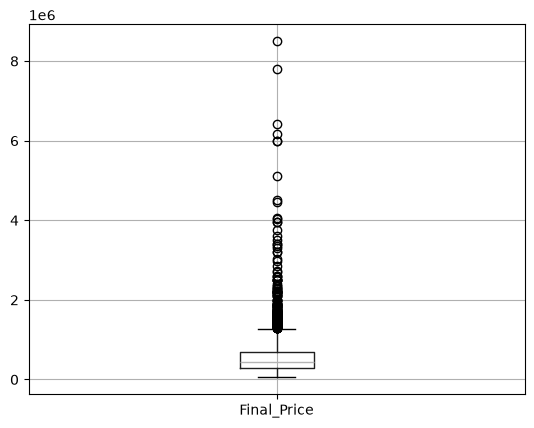

In [85]:
df[["Final_Price"]].boxplot()

In [ ]:
## droping raw price columns 

In [87]:
df.drop("Price", axis=1, inplace=True)

In [88]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,"EMI ₹6,824/m*",Petrol,Manual,259000.0
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,"EMI ₹8,915/m*",Petrol,Auto,505000.0
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,"EMI ₹6,762/m*",Petrol,Manual,304000.0
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,"EMI ₹3,982/m*",Petrol,Auto,151000.0
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,"EMI ₹6,847/m*",Diesel,Manual,260000.0
...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,"EMI ₹18,730/m*",Petrol,Auto,1094000.0
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,Not available on EMI,Diesel,Manual,239000.0
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,"EMI ₹15,975/m*",Petrol,Auto,933000.0
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,"EMI ₹9,630/m*",Petrol,Manual,366000.0


# EMI

In [89]:
df["EMI"]

0              EMI ₹6,824/m*
1              EMI ₹8,915/m*
2              EMI ₹6,762/m*
3              EMI ₹3,982/m*
4              EMI ₹6,847/m*
                ...         
3146          EMI ₹18,730/m*
3148    Not available on EMI
3149          EMI ₹15,975/m*
3150           EMI ₹9,630/m*
3151           EMI ₹8,920/m*
Name: EMI, Length: 3032, dtype: str

In [91]:
df["EMI"] = df["EMI"].str.extract(r"₹([\d,]+)")

In [92]:
df["EMI"]

0        6,824
1        8,915
2        6,762
3        3,982
4        6,847
         ...  
3146    18,730
3148       NaN
3149    15,975
3150     9,630
3151     8,920
Name: EMI, Length: 3032, dtype: str

In [94]:
df["EMI"] = df["EMI"].str.replace(",","")
df["EMI"]

0        6824
1        8915
2        6762
3        3982
4        6847
        ...  
3146    18730
3148      NaN
3149    15975
3150     9630
3151     8920
Name: EMI, Length: 3032, dtype: str

In [97]:
df["EMI"] = df["EMI"].astype(float)

In [99]:
df["EMI"]

0        6824.0
1        8915.0
2        6762.0
3        3982.0
4        6847.0
         ...   
3146    18730.0
3148        NaN
3149    15975.0
3150     9630.0
3151     8920.0
Name: EMI, Length: 3032, dtype: float64

In [100]:
df.info()

<class 'pandas.DataFrame'>
Index: 3032 entries, 0 to 3151
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Brand        3032 non-null   str    
 1   Variant      3032 non-null   str    
 2   Model Year   3032 non-null   int64  
 3   City         3032 non-null   str    
 4   Kilometer    3032 non-null   int64  
 5   EMI          2832 non-null   float64
 6   Fuel_Type    3032 non-null   str    
 7   Drive_Mode   3032 non-null   str    
 8   Final_Price  3032 non-null   float64
dtypes: float64(2), int64(2), str(5)
memory usage: 301.4 KB


##  Fuel_Type

In [102]:
df["Fuel_Type"].value_counts()

Fuel_Type
Petrol      2073
Diesel       834
CNG          121
Electric       4
Name: count, dtype: int64

In [103]:
df["Fuel_Type"].isna().sum()

np.int64(0)

## Drive_Mode   

In [104]:
df["Drive_Mode"].value_counts()

Drive_Mode
Manual    2244
Auto       788
Name: count, dtype: int64

### Client meeting 

In [ ]:
# car age 
# km_per_year 
# price_segment 
# age_bucket

In [105]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000.0
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000.0
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000.0
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000.0
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000.0
...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,18730.0,Petrol,Auto,1094000.0
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,NaN,Diesel,Manual,239000.0
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,15975.0,Petrol,Auto,933000.0
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,9630.0,Petrol,Manual,366000.0


## car_age

In [106]:
CURRENT_YEAR = 2026
df["Car_Age"] = CURRENT_YEAR - df["Model Year"] 

In [108]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price,Car_Age
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000.0,11
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000.0,7
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000.0,9
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000.0,11
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000.0,10
...,...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,18730.0,Petrol,Auto,1094000.0,4
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,NaN,Diesel,Manual,239000.0,15
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,15975.0,Petrol,Auto,933000.0,5
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,9630.0,Petrol,Manual,366000.0,11


## km_per_year 

In [111]:
df["km_per_year"] = round(df["Kilometer"] / df["Car_Age"],1)
df["km_per_year"]

0        5014.5
1       12102.7
2        3831.4
3        4211.5
4        9851.6
         ...   
3146    22243.5
3148     3693.6
3149    10688.2
3150     8589.0
3151     2116.5
Name: km_per_year, Length: 3032, dtype: float64

## # price_segment 

In [ ]:
vehicles are categorized into price ranges: 
budegt - upto 5L
mid - 5-10 
upper-mid - 10-20 
premium - 20L


In [112]:
max(df["Final_Price"])

8500000.0

In [117]:
bins = [0,500000,1000000,2000000,10000000]
labels = ["Budget","Mid","Upper-Mid","Premium"]
df["Price_Segment"] = pd.cut(df["Final_Price"], bins= bins, labels = labels)

In [118]:
df["Price_Segment"].value_counts()

Price_Segment
Budget       1763
Mid           916
Upper-Mid     295
Premium        58
Name: count, dtype: int64

In [119]:
df["Price_Segment"].value_counts()/df.shape[0] * 100

Price_Segment
Budget       58.146438
Mid          30.211082
Upper-Mid     9.729551
Premium       1.912929
Name: count, dtype: float64

## age bucket 

In [ ]:
vechiels are grouped into age group 

0-3 year 
4-6 year 
7-10 year 
10+ year 

In [121]:
bins = [0,3,6,10,20]
labels = ["0-3","4-6","7-10","10+"]
df["Age_Bucket"] = pd.cut(df["Car_Age"], bins= bins, labels= labels)

In [122]:
df["Age_Bucket"].value_counts()

Age_Bucket
7-10    1157
4-6      789
10+      738
0-3      348
Name: count, dtype: int64

In [123]:
df

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price,Car_Age,km_per_year,Price_Segment,Age_Bucket
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000.0,11,5014.5,Budget,10+
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000.0,7,12102.7,Mid,7-10
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000.0,9,3831.4,Budget,7-10
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000.0,11,4211.5,Budget,10+
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000.0,10,9851.6,Budget,7-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3146,Volkswagen,TAIGUN TOPLINE 1.0 TSI AT,2022,Coimbatore,88974,18730.0,Petrol,Auto,1094000.0,4,22243.5,Upper-Mid,4-6
3148,Volkswagen,Vento HIGHLINE DIESEL 1.,2011,Coimbatore,55404,NaN,Diesel,Manual,239000.0,15,3693.6,Budget,10+
3149,Volkswagen,Polo 1.0 GT TSI AT,2021,Coimbatore,53441,15975.0,Petrol,Auto,933000.0,5,10688.2,Mid,4-6
3150,Volkswagen,Polo HIGHLINE1.2L,2015,Coimbatore,94479,9630.0,Petrol,Manual,366000.0,11,8589.0,Budget,10+


# final clean dataset 

In [124]:
df.to_csv(r"data/clean/car_clean.csv")

## Univariate Analysis 

### distribution of resale Price 

In [126]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'EMI',
       'Fuel_Type', 'Drive_Mode', 'Final_Price', 'Car_Age', 'km_per_year',
       'Price_Segment', 'Age_Bucket'],
      dtype='str')

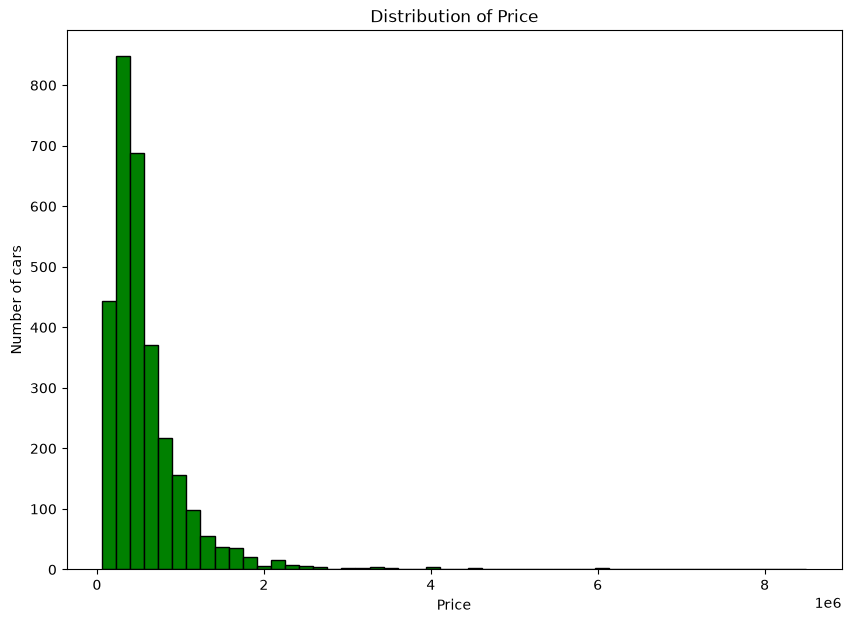

In [133]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(10,7))
plt.hist(df["Final_Price"], bins=50, color="Green",edgecolor="black")
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Number of cars")
plt.show()

In [ ]:
# observation 
1. price distribution is right -skewed 
2. most of card are price below 2 lakhs 

### kilometers

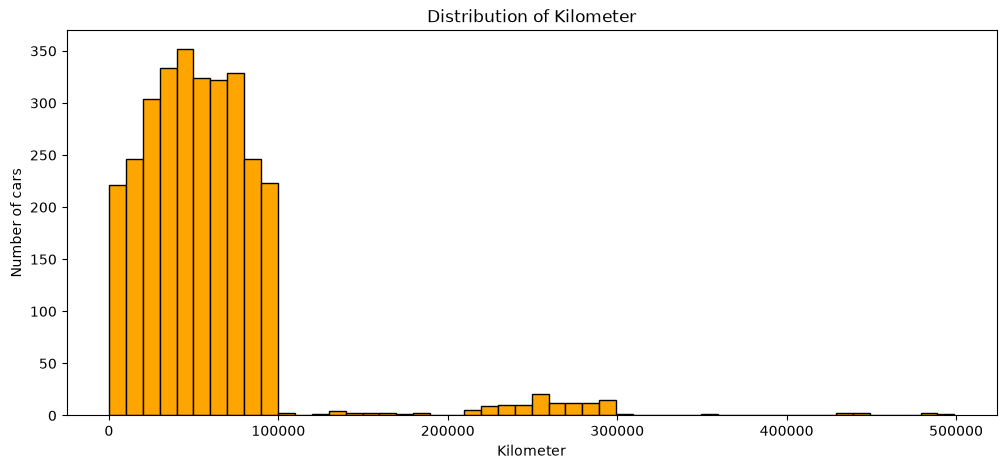

In [138]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(12,5))
plt.hist(df["Kilometer"], bins=50, color="Orange",edgecolor="black")
plt.title("Distribution of Kilometer")
plt.xlabel("Kilometer")
plt.ylabel("Number of cars")
plt.show()

# car Age

In [139]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'EMI',
       'Fuel_Type', 'Drive_Mode', 'Final_Price', 'Car_Age', 'km_per_year',
       'Price_Segment', 'Age_Bucket'],
      dtype='str')

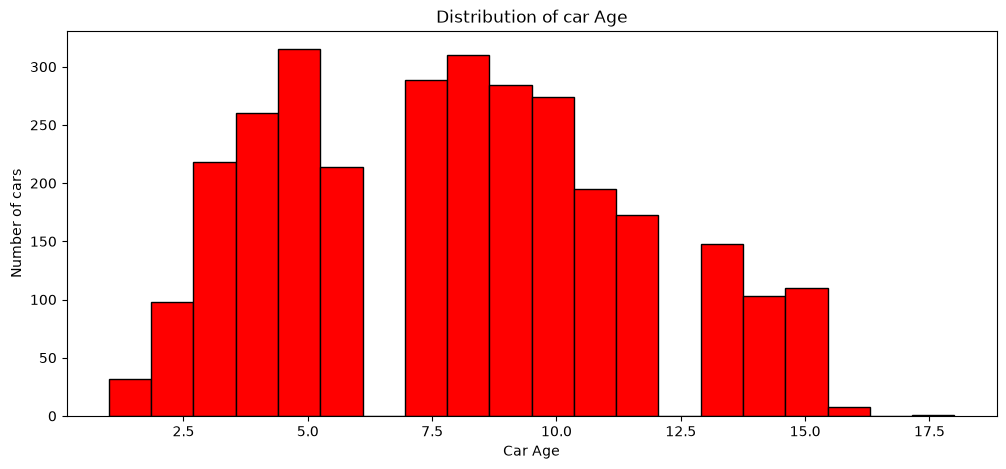

In [143]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(12,5))
plt.hist(df["Car_Age"], bins=20, color="Red",edgecolor="black")
plt.title("Distribution of car Age")
plt.xlabel("Car Age")
plt.ylabel("Number of cars")
plt.show()

## Bivariate Analysis

#### brand - wise resale prcie 

In [145]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'EMI',
       'Fuel_Type', 'Drive_Mode', 'Final_Price', 'Car_Age', 'km_per_year',
       'Price_Segment', 'Age_Bucket'],
      dtype='str')

In [147]:
df["Brand"].value_counts()

Brand
Maruti        337
Tata          336
Hyundai       331
Honda         327
Ford          293
Mahindra      276
Renault       270
Toyota        261
Volkswagen    249
KIA           246
BMW           106
Name: count, dtype: int64

In [149]:
df.groupby("Brand")["Final_Price"].mean()

Brand
BMW           1.570500e+06
Ford          3.676553e+05
Honda         4.389694e+05
Hyundai       4.894622e+05
KIA           1.022175e+06
Mahindra      7.974420e+05
Maruti        3.807953e+05
Renault       3.367815e+05
Tata          5.715982e+05
Toyota        7.511877e+05
Volkswagen    4.215462e+05
Name: Final_Price, dtype: float64

In [154]:
brand_avg_price = df.groupby("Brand")["Final_Price"].mean()
brand_avg_price = brand_avg_price.sort_values(ascending=False)

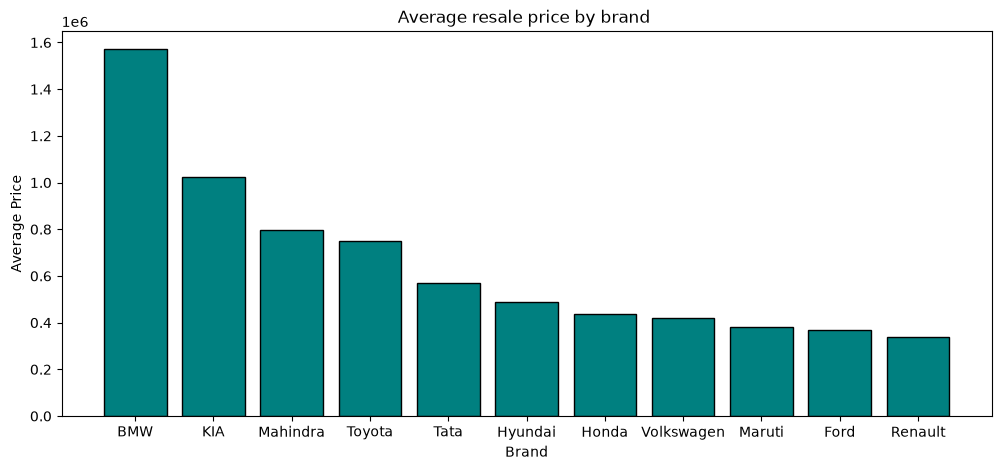

In [155]:
plt.figure(figsize=(12,5))
plt.bar(brand_avg_price.index,brand_avg_price.values, color="teal",edgecolor="black")
plt.title("Average resale price by brand ")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.show()

In [156]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'EMI',
       'Fuel_Type', 'Drive_Mode', 'Final_Price', 'Car_Age', 'km_per_year',
       'Price_Segment', 'Age_Bucket'],
      dtype='str')

## Average price by fuel type

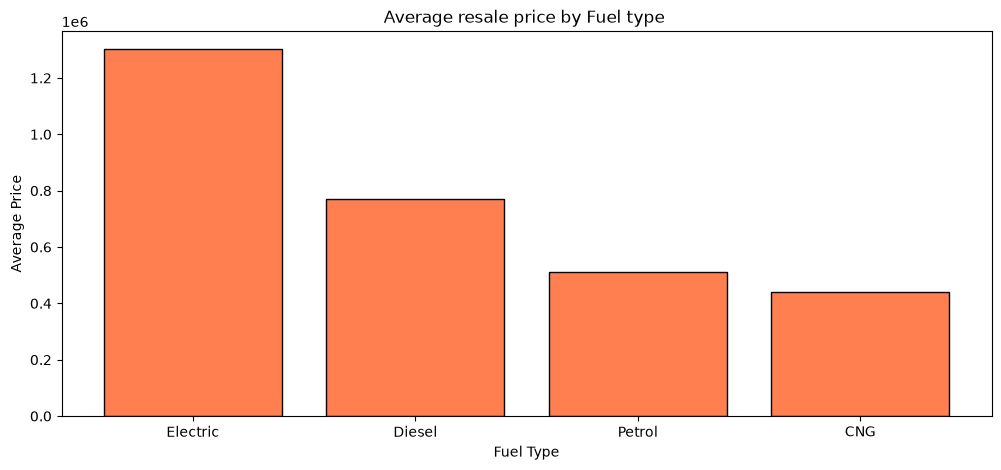

In [158]:
fuel_avg_price = df.groupby("Fuel_Type")["Final_Price"].mean()
fuel_avg_price = fuel_avg_price.sort_values(ascending=False)
plt.figure(figsize=(12,5))
plt.bar(fuel_avg_price.index,fuel_avg_price.values, color="coral",edgecolor="black")
plt.title("Average resale price by Fuel type ")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")
plt.show()

### Multivariate Analysis

#### brand-wise Price distribution 

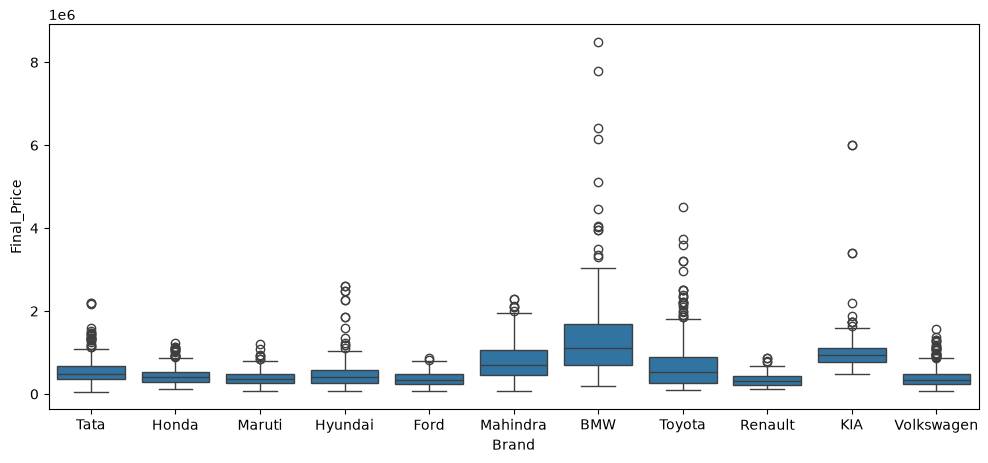

In [160]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df , x = "Brand", y = "Final_Price")
plt.show()

In [161]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'EMI',
       'Fuel_Type', 'Drive_Mode', 'Final_Price', 'Car_Age', 'km_per_year',
       'Price_Segment', 'Age_Bucket'],
      dtype='str')

### price by Fuel Type and Transmission

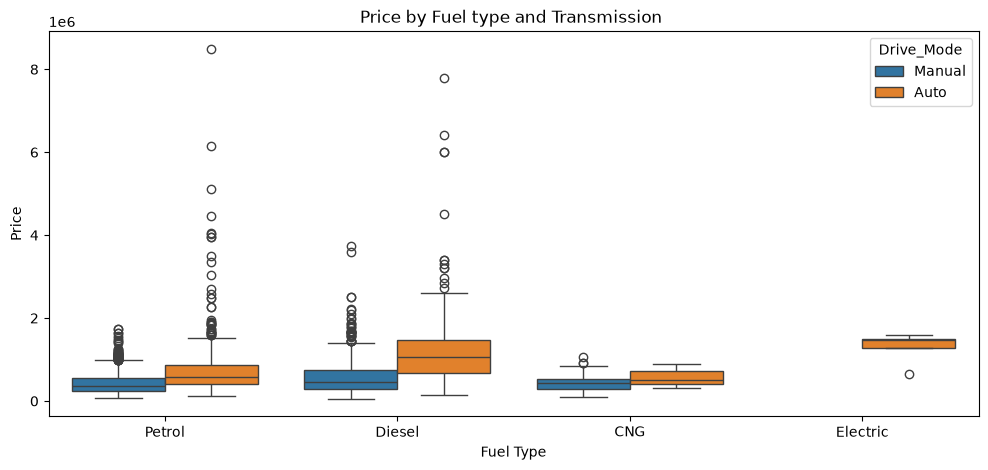

In [162]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df , x = "Fuel_Type", y = "Final_Price", hue="Drive_Mode")
plt.title("Price by Fuel type and Transmission ")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.show()


### correlation heatmap 

In [165]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'EMI',
       'Fuel_Type', 'Drive_Mode', 'Final_Price', 'Car_Age', 'km_per_year',
       'Price_Segment', 'Age_Bucket'],
      dtype='str')

In [167]:
df.info()



<class 'pandas.DataFrame'>
Index: 3032 entries, 0 to 3151
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Brand          3032 non-null   str     
 1   Variant        3032 non-null   str     
 2   Model Year     3032 non-null   int64   
 3   City           3032 non-null   str     
 4   Kilometer      3032 non-null   int64   
 5   EMI            2832 non-null   float64 
 6   Fuel_Type      3032 non-null   str     
 7   Drive_Mode     3032 non-null   str     
 8   Final_Price    3032 non-null   float64 
 9   Car_Age        3032 non-null   int64   
 10  km_per_year    3032 non-null   float64 
 11  Price_Segment  3032 non-null   category
 12  Age_Bucket     3032 non-null   category
dtypes: category(2), float64(3), int64(3), str(5)
memory usage: 355.1 KB


<Axes: >

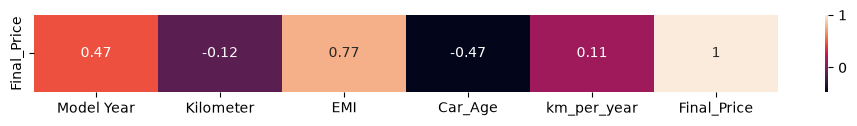

In [173]:
numeric_cols = ['Model Year','Kilometer', 'EMI', 'Car_Age', 'km_per_year','Final_Price']
corr = df[numeric_cols].corr()
plt.figure(figsize=(12,1))
sns.heatmap(corr.tail(1),annot=True)

# Step 5: Fetaure Selection

In [ ]:
1. Filter methods
2. Wrapper method 
3. Emebeded method 

In [174]:
df.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'EMI',
       'Fuel_Type', 'Drive_Mode', 'Final_Price', 'Car_Age', 'km_per_year',
       'Price_Segment', 'Age_Bucket'],
      dtype='str')

In [183]:
df["Brand"].value_counts().shape

(11,)

In [184]:
df1 = df.copy()

In [188]:
df1.shape

(3032, 13)

In [189]:
encoded_df = pd.get_dummies(df1,columns = ["Brand"])

In [191]:
encoded_df.shape

(3032, 23)

In [193]:
df1.head()

,Brand,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price,Car_Age,km_per_year,Price_Segment,Age_Bucket
0,Tata,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000.0,11,5014.5,Budget,10+
1,Tata,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000.0,7,12102.7,Mid,7-10
2,Tata,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000.0,9,3831.4,Budget,7-10
3,Tata,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000.0,11,4211.5,Budget,10+
4,Tata,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000.0,10,9851.6,Budget,7-10


In [192]:
encoded_df.head()

,Variant,Model Year,City,Kilometer,EMI,Fuel_Type,Drive_Mode,Final_Price,Car_Age,km_per_year,...,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_KIA,Brand_Mahindra,Brand_Maruti,Brand_Renault,Brand_Tata,Brand_Toyota,Brand_Volkswagen
0,Zest XE PETROL,2015,Hyderabad,55160,6824.0,Petrol,Manual,259000.0,11,5014.5,...,False,False,False,False,False,False,False,True,False,False
1,NEXON XZA PLUS PETROL DUAL TONE,2019,Hyderabad,84719,8915.0,Petrol,Auto,505000.0,7,12102.7,...,False,False,False,False,False,False,False,True,False,False
2,TIGOR XZ (O) PETROL,2017,Hyderabad,34483,6762.0,Petrol,Manual,304000.0,9,3831.4,...,False,False,False,False,False,False,False,True,False,False
3,Nano TWIST XTA,2015,Hyderabad,46327,3982.0,Petrol,Auto,151000.0,11,4211.5,...,False,False,False,False,False,False,False,True,False,False
4,Tiago XE DIESEL,2016,Hyderabad,98516,6847.0,Diesel,Manual,260000.0,10,9851.6,...,False,False,False,False,False,False,False,True,False,False


In [195]:
df["Variant"].nunique()

996

# Final Features 

In [175]:
categorical_features = ['Brand','Variant','City','Fuel_Type', 'Drive_Mode']
Numerical_features = ['Model Year','Kilometer','Car_Age','km_per_year',]

# Step 6 : Model 

In [176]:
from sklearn.model_selection import train_test_split


In [177]:
X = df.drop("Final_Price", axis=1)
y = df["Final_Price"]

In [201]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42,)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2425, 12), (607, 12), (2425,), (607,))

In [226]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num","passthrough",Numerical_features),
        ("cat",OneHotEncoder(handle_unknown='ignore',),categorical_features)
    ]
)

# Linear Regression

In [227]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
lr_model = LinearRegression()

lr_pipeline = Pipeline(
                [
                    ("preprocessor",preprocessor),
                    ("model",lr_model)
                ]
            )

lr_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Brand','Variant','Model Year',...,'km_per_year','Price_Segment', 'Age_Bucket']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o

# Step 7: Model Evaluation 

In [228]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [229]:
def model_eval(actual,perd):
    mae = mean_absolute_error(actual,perd)
    mse = mean_squared_error(actual,perd)
    r2 = r2_score(actual,perd)

    print(f"Mean Absolute Error = {mae}")
    print(f"Mean Sqaured Error = {mse}")
    print(f"R2 Score = {r2}")

    return mae,mse,r2

In [230]:
# on testing data 
y_pred = lr_pipeline.predict(X_test)
model_eval(y_test,y_pred)

## on training data 
y_pred = lr_pipeline.predict(X_train)
model_eval(y_train,y_pred)

Mean Absolute Error = 214967.71385338847
Mean Sqaured Error = 157108526026.72318
R2 Score = 0.4685155489523011
Mean Absolute Error = 198920.83025281838
Mean Sqaured Error = 133904255840.56613
R2 Score = 0.5418840442701205


(198920.83025281838, 133904255840.56613, 0.5418840442701205)

In [220]:
ignore_list =  ['Creta S 1.6 PETROL', 'X1 sDrive20i xLine', 'i20 ERA 1.', 'CARENS LUXURY PLUS 1.4 PETROL 7 STR', 'Creta SX AT 1.6 DIESEL', 'Bolero 2WD 7 SEATER', 'i20 Active 1.2 SX', 'Endeavour 2.5L 4X2 AT', 'SONET HTX ANNIVERSARY EDITION 1.5 AT', 'SELTOS HTE 1.5 DIESEL', 'Captur RXT DIESEL DUAL TONE', 'X1 sDrive 20d Expedition', 'TAIGUN  GT PLUS 1.5 TSI MT', 'NEW SANTRO SPORTZ CNG', 'Swift VXI O', 'XUV500 W10 1.', 'Fiesta SXI 1.4 DIESEL', 'NEXON XZA PLUS SUNROOF DARK PETROL', 'EXTER S 1.2 CNG MT', 'ALCAZAR PLATINUM(O) 6STR 1.5 AT', 'Amaze 1.5L I-DTEC SX', 'CARENS Premium (O) 1.5 Petrol 7 STR', 'Creta SX (O) 1.6 PETROL', 'Curvv Accomplished S 1.2 Petrol 7DCA', 'CARENS LUXURY PLUS 1.4 PETROL DCT 7 STR', 'MARAZZO M2 7STR', 'XUV700 AX 5 D AT 7 STR', 'Elite i20 MAGNA 1.', 'TUV300 T6 PLUS', 'EXTER  SX 1.2 AMT', 'NEXON SMART+ 1.2 PETROL', '5 Series 530I M SPORT', 'XL6 ALPHA AT', 'Jazz 1.5L I-DTEC SV', 'Swift LDI', 'Swift Dzire ZXI', 'NEXON XZ PLUS (PREMIUM) KAZIRANGA PETROL', 'NEXON XZ PLUS (PREMIUM) PETROL', 'SONET X LINE 1.5 AT', 'YARIS V MT', 'Classic 1.4 TITANIUM DIESEL', 'Vitara Brezza ZXI', 'SCORPIO CLASSIC S11 7STR', 'Fortuner 2.8 4X2 AT', 'SELTOS GTX PLUS 1.5 DIESEL AT', 'Etios CROSS 1.5 V', 'XL6 ZETA AT', 'Safari XZ PLUS DARK EDITION', 'CARENS LUXURY PLUS 1.5 IMT PETROL', 'Dzire ZXI PLUS', 'TIAGO EV XT LONG RANGE', 'Duster 110 PS RXS MT DIESEL', 'IGNIS ALPHA 1.2 DUAL TONE', 'PUNCH ACCOMPLISHED MT CNG', 'Verna 1.6 VTVT SX O', 'FREESTYLE TITANIUM 1.2 PETROL', 'Jetta COMFORTLINE TDI', 'Swift VDI AMT', 'TIAGO NRG XZ AMT', 'TAIGUN GT PLUS 1.5 TSI DSG', 'Ecosport TITANIUM+ 1.0L ECOBOOST', 'Indica Vista VX QUADRAJET', 'XUV300 W4 1.5 DIESEL', 'Cross Polo HIGHLINE TDI', 'Etios Liva VX', 'NEXON XZ PETROL', 'SELTOS  HTE 1.5 PETROL MT', 'TIAGO NRG  NRG XZA CNG', '5 Series 530i M Sport', 'City 1.5L I-VTEC VX (O) MT', 'X7 xDrive 40i', 'FREESTYLE TITANIUM PLUS 1.5 DIESEL', 'AURA SX PLUS 1.2 AMT', 'Thar LX D 4WD AT CONVERTIBLE', 'ALTROZ XZ Plus (S) LUX', 'Swift ZXi Plus Dual Tone AMT', 'Verna 1.6 VTVT SX AT', 'Vento TRENDLINE DIESEL 1.', 'Polo COMFORTLINE 1.0L TSI AT', 'NEW I20 ASTA (O) 1.2 IVT', 'SONET HTK PLUS 1.5 IMT', 'XUV300 W8(O) 1.2 PETROL DUAL TONE', '5 Series 520D LUXURY LINE', 'S PRESSO VXI AMT', 'SELTOS HTE (O)1.5 Petrol MT', 'SONET GTX Plus 1.0 Turbo Petrol DCT Dual Tone', 'ALTROZ XM PETROL', 'Mobilio 1.5L I-DTEC S', 'BREZZA VXI SMART HYBRID', 'S PRESSO VXI (O)', 'YARIS VX MT', 'Camry 2.5L AT', 'KUV 100 NXT K2 D 6S', 'Verna 1.6 SX (O) CRDI MT', 'XUV500 W8 AWD', 'Verna FLUIDIC 1.6 CRDI SX AT', 'Xcent SX AT 1.2 (O)', 'TIGOR XZ PLUS CNG', 'ALTROZ XZA PLUS', 'New Elantra 2.0 SX(O) AT PETROL', 'Zest XE PETROL', 'Ertiga VXI AT', 'VENUE SX 1.0 (O) TURBO', 'MARAZZO M6 8 STR'] 
len(ignore_list)

104

In [222]:
len(X_test)

607

In [223]:
607-104

503

In [224]:
104/607 *100

17.1334431630972

In [225]:
104*.8

83.2

# Bias and variance 

In [ ]:
Bias >> high 
varaince >> low 

Underfit 

## Random Forest 

In [208]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf_pipeline = Pipeline(
                [
                    ("preprocessor",preprocessor),
                    ("model",rf)
                ]
            )

rf_pipeline.fit(X_train,y_train)

# on testing data 
y_pred = rf_pipeline.predict(X_test)
model_eval(y_test,y_pred)

## on training data 
y_pred = rf_pipeline.predict(X_train)
model_eval(y_train,y_pred)

Mean Absolute Error = 118037.71004942339
Mean Sqaured Error = 66777136507.65146
R2 Score = 0.7740987670314621
Mean Absolute Error = 41726.724398625425
Mean Sqaured Error = 7224042962.391752
R2 Score = 0.975284957709707


(41726.724398625425, 7224042962.391752, 0.975284957709707)

### bias and variance 

In [ ]:
Bias >> low 
varaince >> high 

Overfit

## xgboost 

In [209]:
from xgboost import XGBRegressor

In [214]:
xgb = XGBRegressor(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8, 
    objective = "reg:squarederror",
    random_state = 42
)

xgb_pipeline = Pipeline(
                [
                    ("preprocessor",preprocessor),
                    ("model",xgb)
                ]
            )

xgb_pipeline.fit(X_train,y_train)

# on testing data 
y_pred = xgb_pipeline.predict(X_test)
model_eval(y_test,y_pred)

## on training data 
y_pred = xgb_pipeline.predict(X_train)
model_eval(y_train,y_pred)

Mean Absolute Error = 121124.26998815898
Mean Sqaured Error = 58464329894.582504
R2 Score = 0.8022202673163107
Mean Absolute Error = 73921.16618234536
Mean Sqaured Error = 9278469134.379253
R2 Score = 0.9682563132252693


(73921.16618234536, 9278469134.379253, 0.9682563132252693)

In [ ]:
Bias >> low 
varaince >> high 

Overfit

# Hyperparameter Tuning

In [231]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

In [234]:
xg_hy_model = XGBRegressor(random_state=42)

pipeline = Pipeline(
                [
                    ("preprocessor",preprocessor),
                    ("model",xg_hy_model)
                ]
            )

hyp = {
    "model__n_estimators": [200,400,600,800],
    "model__learning_rate" :[0.01,0.07,0.1],
    "model__max_depth" :[4,5,7,8,9],
    "model__subsample" : [0.7,0.9,1.0]
}

rscv = RandomizedSearchCV(pipeline,hyp, random_state=42,n_jobs=-1)
rscv.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.07, ...], 'model__max_depth': [4, 5, ...], 'model__n_estimators': [200, 400, ...], 'model__subsample': [0.7, 0.9, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term

In [235]:
rscv.best_params_

{'model__subsample': 0.9,
 'model__n_estimators': 800,
 'model__max_depth': 9,
 'model__learning_rate': 0.07}

In [236]:
rscv.best_score_

np.float64(0.7925264326142966)

In [237]:
hyp_model = rscv.best_estimator_
# on testing data 
y_pred = hyp_model.predict(X_test)
model_eval(y_test,y_pred)

## on training data 
y_pred = hyp_model.predict(X_train)
model_eval(y_train,y_pred)

Mean Absolute Error = 115528.29606414745
Mean Sqaured Error = 66874124989.35173
R2 Score = 0.7737706634507204
Mean Absolute Error = 30967.773009020617
Mean Sqaured Error = 1516968573.6931915
R2 Score = 0.9948101163507671


(30967.773009020617, 1516968573.6931915, 0.9948101163507671)

# Save the model 

In [242]:
import os 
import pickle 

os.makedirs("model",exist_ok=True)
with open("model/xgb_model.pkl","wb") as model: 
    pickle.dump(xgb_pipeline,model)

In [248]:
X_train.head(1).to_numpy()

array([['Volkswagen', 'Polo COMFORTLINE 1.2L PETROL', 2011, 'New-delhi',
        21775, nan, 'Petrol', 'Manual', 15, 1451.7, 'Budget', '10+']],
      dtype=object)

In [249]:
X_train.columns

Index(['Brand', 'Variant', 'Model Year', 'City', 'Kilometer', 'EMI',
       'Fuel_Type', 'Drive_Mode', 'Car_Age', 'km_per_year', 'Price_Segment',
       'Age_Bucket'],
      dtype='str')

In [252]:
dict(zip(X_train.columns,X_train.head(1).to_numpy()[0]))

{'Brand': 'Volkswagen',
 'Variant': 'Polo COMFORTLINE 1.2L PETROL',
 'Model Year': 2011,
 'City': 'New-delhi',
 'Kilometer': 21775,
 'EMI': nan,
 'Fuel_Type': 'Petrol',
 'Drive_Mode': 'Manual',
 'Car_Age': 15,
 'km_per_year': 1451.7,
 'Price_Segment': 'Budget',
 'Age_Bucket': '10+'}

In [255]:
X_train.iloc[3]

Brand                            Mahindra
Variant          XUV300 W8 (O) 1.2 PETROL
Model Year                           2022
City                            New-delhi
Kilometer                           33154
EMI                               13504.0
Fuel_Type                          Petrol
Drive_Mode                         Manual
Car_Age                                 4
km_per_year                        8288.5
Price_Segment                         Mid
Age_Bucket                            4-6
Name: 1271, dtype: object

In [256]:
X_train["Brand"].value_counts()

Brand
Tata          272
Honda         270
Hyundai       268
Maruti        263
Ford          233
Mahindra      215
Renault       215
Toyota        214
Volkswagen    198
KIA           194
BMW            83
Name: count, dtype: int64